# **Razón Estandarizada de Morbilidad**
$$
REM_{Atlántico} = \frac{O_{Casos}}{E_{Tasa}}
$$

donde:  
- $ OBS_{casos} $= Casos observados en el departamento  
- $ ESP_{Tasa} $ = Casos esperados según la tasa departamental de incidencia.

El $REM$ es una medida estadística utilizada en salud pública para comparar la morbilidad observada en una población con la que se esperaría si la población tuviera la misma tasa de morbilidad que una población de referencia.

|Valor REM | Descripción |
|-------|-------------|
|<1 | Menos casos de lo esperado |
| 1 | Casos igual al esperado | 
| >1| Más casos de lo esperado | 


In [1]:
# [Configuración] Imports
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import seaborn as sns

In [2]:
total_año = pd.read_csv("https://raw.githubusercontent.com/Darally06/ETL_DENGUE/refs/heads/main/DATA/REM/REM_Total_A%C3%B1o.csv")
total_mun = pd.read_csv("https://raw.githubusercontent.com/Darally06/ETL_DENGUE/refs/heads/main/DATA/REM/REM_Total_Municipio.csv")
periodo_mun = pd.read_csv("https://raw.githubusercontent.com/Darally06/ETL_DENGUE/refs/heads/main/DATA/REM/REM_periodo_municipio.csv")

mapa_atl = gpd.read_file("./MAPAS/MAPAS_MUN/MGN_ADM_MPIO_GRAFICO.shp")
mapa_atl = mapa_atl.rename(columns={'mpio_cnmbr': 'municipio'})
mapa_atl = mapa_atl[mapa_atl['dpto_cnmbr'] == 'ATLÁNTICO']

## REM por año

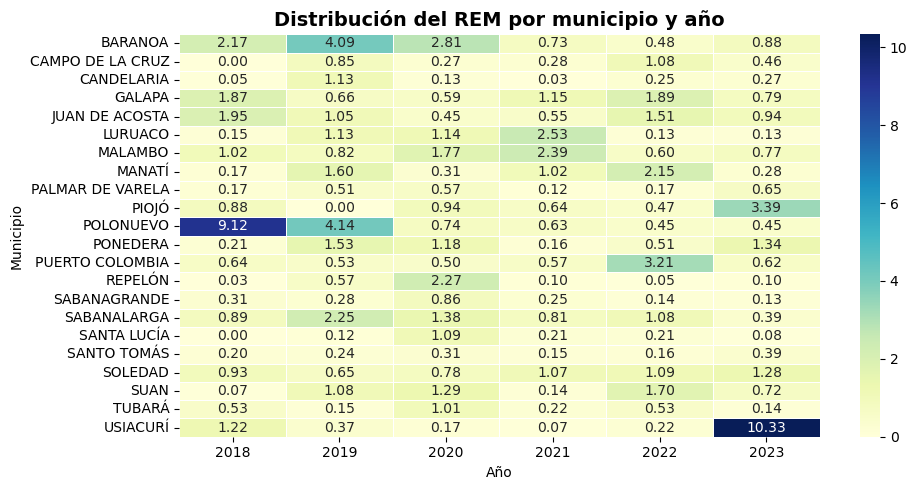

In [7]:
pivot_heat = total_año.pivot(index="MUNICIPIO", columns="año", values="REM")
plt.figure(figsize=(10, 5))

sns.heatmap(
    pivot_heat,
    annot=True,         # Mostrar valores dentro del recuadro
    fmt=".2f",          # Formato de decimales
    cmap="YlGnBu",    # Colormap (puedes usar Blues, Viridis, etc.)
    linewidths=0.5,
    linecolor="white"
)

plt.title("Distribución del REM por municipio y año", fontsize=14, fontweight='bold')
plt.xlabel("Año")
plt.ylabel("Municipio")
plt.tight_layout()
plt.show()


De acuerdo al REM calculado a partir de los casos registrados en el Atlántico se observa una dinámica diversa. Se pone especial detalle, en el municipio de Usiacurí que en el año 2023 presentó el REM más alto (10.33), indicando que este año la morbilidad fue 10 veces superior a lo esperado. Por su parte, Polonuevo en el 2018 presentó una morbilidad de 9.12 alta de lo esperado, seguido 

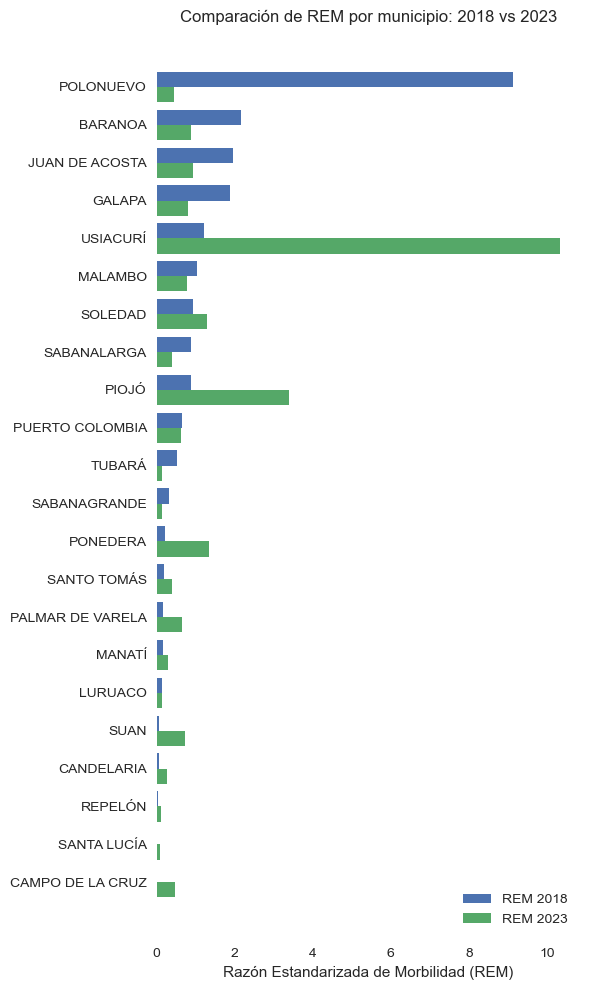

In [ ]:
# --- Filtrar años relevantes ---
df_rem = total_año[total_año["año"].isin([2018, 2023])]
df_rem = df_rem.sort_values("año").drop_duplicates(subset=["MUNICIPIO", "año"], keep="last")
pivot_rem = df_rem.pivot(index="MUNICIPIO", columns="año", values="REM").fillna(0)
pivot_rem = pivot_rem.sort_values(by=2018, ascending=False)

# --- Graficar ---
fig, ax = plt.subplots(figsize=(6, 10))
x = range(len(pivot_rem))
height = 0.4

ax.barh([i - height/2 for i in x], pivot_rem[2018], height=height, label="REM 2018")
ax.barh([i + height/2 for i in x], pivot_rem[2023], height=height, label="REM 2023")

ax.set_yticks(list(x))
ax.set_yticklabels(pivot_rem.index)

ax.invert_yaxis()  # <-- IMPORTANTE: municipios arriba–abajo en el orden correcto

ax.set_facecolor("white")
ax.set_xlabel("Razón Estandarizada de Morbilidad (REM)")
ax.set_title("Comparación de REM por municipio: 2018 vs 2023")
ax.legend()
plt.tight_layout()
plt.show()


## REM por municipio

In [5]:
total_mun = total_mun.rename(columns={"MUNICIPIO": "municipio"})
mapa_mun = mapa_atl.merge(total_mun, on='municipio', how='left')


C:\Users\danie\AppData\Local\Temp\ipykernel_11604\1480483060.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('YlGnBu', len(labels))


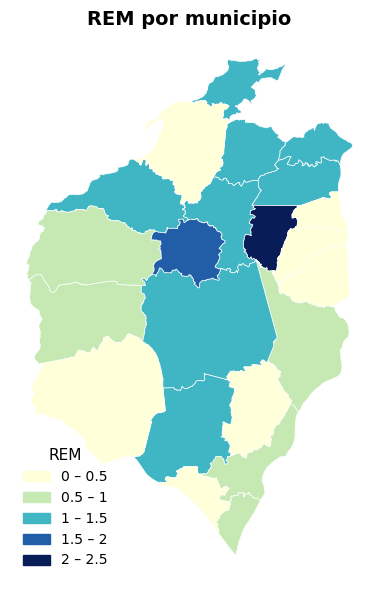

In [20]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib.cm as cm

bins = [0, 0.5, 1, 1.5, 2, 2.5] 
labels = [ "0 – 0.5", "0.5 – 1", "1 – 1.5","1.5 – 2", "2 – 2.5" ]

fig, ax = plt.subplots(figsize=(10, 6))

mapa_mun.plot(
    column='casos_cat',
    cmap='YlGnBu',
    linewidth=0.5,
    edgecolor='1',
    ax=ax
)

cmap = cm.get_cmap('YlGnBu', len(labels))
patches = [
    mpatches.Patch(color=cmap(i), label=label)
    for i, label in enumerate(labels)
]

ax.legend(
    handles=patches,
    title="REM",
    loc='lower left',
    frameon=False,
    fontsize=10,
    title_fontsize=11
)

ax.set_title("REM por municipio", fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

La dinámica del REM, en el periodo de estudio es muy parecida a la de la incidencia de los casos. Centrada en el centro del departamento, con menos concentracion hacia los extremos. Municipios como tubara, repelon, .... tienen muy baja morbilidad. Por otro lado, [verde claro]

### 🟨 **0 – 0.5 (amarillo claro)**
- Municipios con **muy baja morbilidad**.

### 🟩 **0.5 – 1 (verde claro)**
- Morbilidad **ligeramente menor a lo esperado**.

### 🔵 **1 – 1.5 (azul claro)**
- Morbilidad **ligeramente mayor a lo esperado**.

### 🔷 **1.5 – 2 (azul medio)**
- Morbilidad **moderadamente alta**.

### 🔵🔵 **2 – 2.5 (azul oscuro)**
- Municipios con **alta morbilidad**.

---

## 📌 Observaciones clave

- **Polonuevo y Usiacurí** destacan por tener REM altos (más del doble de lo esperado).
- **Santa Lucía y Campo de la Cruz** tienen REM cercanos a cero, lo que podría indicar subregistro, baja exposición o buena prevención.
- La distribución no es homogénea: hay **focos de alta morbilidad** rodeados por municipios con REM bajos.


---------

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------
# Cargar los datos
# -----------------------
df = pd.read_csv("C:\ETL_DENGUE\ARCHIVOS\REM\REM_Total_Año.csv")  
df_plot = df[df["año"].isin([2018, 2023])]
df_wide = df_plot.pivot(index="MUNICIPIO", columns="año", values="REM")
df_wide = df_wide.sort_values(2023)

municipios = df_wide.index
rem18 = df_wide[2018]
rem23 = df_wide[2023]

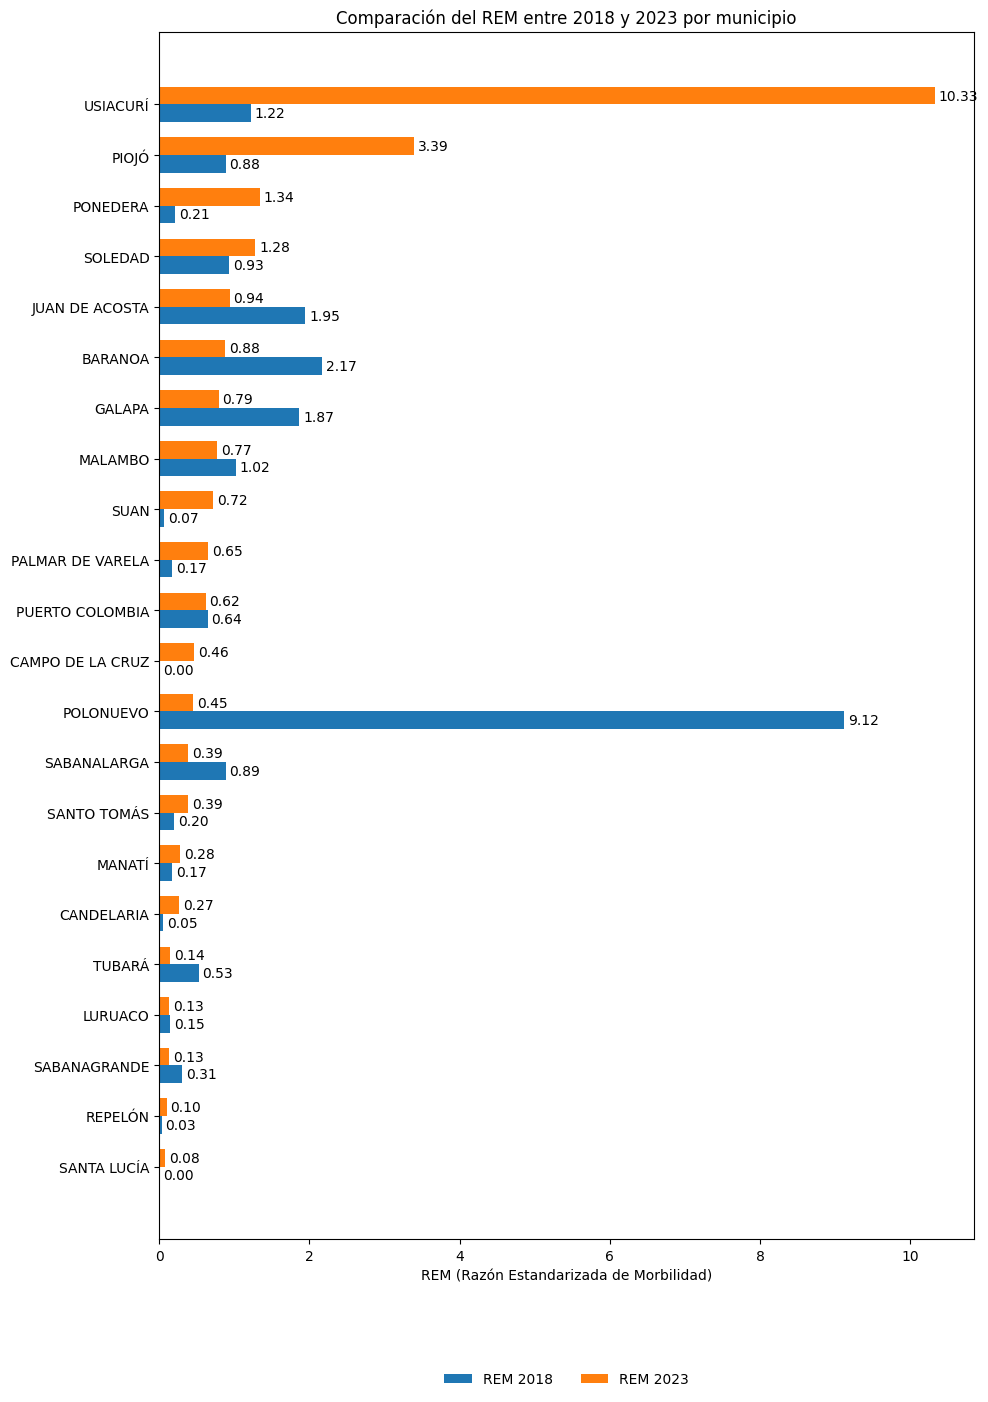

In [ ]:

plt.figure(figsize=(10, 14))

# Más separación entre barras
bar_height = 0.35
y_positions = range(len(municipios))

# Barras 2018 (abajo)
plt.barh(
    [y - bar_height/2 for y in y_positions],
    rem18,
    height=bar_height,
    label="REM 2018"
)

# Barras 2023 (arriba)
plt.barh(
    [y + bar_height/2 for y in y_positions],
    rem23,
    height=bar_height,
    label="REM 2023"
)

# Etiquetas numéricas
for i, v in enumerate(rem18):
    plt.text(v + 0.05, i - bar_height/2, f"{v:.2f}", va="center")

for i, v in enumerate(rem23):
    plt.text(v + 0.05, i + bar_height/2, f"{v:.2f}", va="center")

plt.yticks(list(y_positions), municipios)
plt.xlabel("REM (Razón Estandarizada de Morbilidad)")
plt.title("Comparación del REM entre 2018 y 2023 por municipio")

# Leyenda debajo del gráfico
plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.10),
    ncol=2,
    frameon=False
)

plt.tight_layout()
plt.show()